In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

import psycopg2
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score,
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

MODELS_DIR = Path("/home/ubuntu/threat-intel-platform/ml/models")
REPORTS_DIR = Path("/home/ubuntu/threat-intel-platform/ml/reports")
DATA_DIR = Path("/home/ubuntu/threat-intel-platform/ml/data")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Postgres connection (running locally on EC2)
PG_DSN = "host=localhost port=5432 user=threat password=Personalproject2026-threatintel dbname=threat_intel"
ATTACKER_IP = "10.20.7.205"  # from attack_windows.json

In [2]:
# Load the attack windows JSON
with open(DATA_DIR / 'attack_windows.json') as f:
    windows_data = json.load(f)
windows = windows_data['windows']

print(f"Loaded {len(windows)} windows from collection at {windows_data['collected_at']}")
for w in windows:
    print(f"  {w['label']:12s}  {w['start_ts'][:19]}  ->  {w['label_until_ts'][:19]}")

# Determine the full collection time range
collection_start = min(w['start_ts'] for w in windows)
collection_end = max(w['label_until_ts'] for w in windows)
print(f"\nCollection range: {collection_start} to {collection_end}")

Loaded 7 windows from collection at 2026-05-21T04:31:54.483036+00:00
  BENIGN        2026-05-21T04:12:19  ->  2026-05-21T04:15:54
  PortScan      2026-05-21T04:15:54  ->  2026-05-21T04:17:59
  BENIGN        2026-05-21T04:17:59  ->  2026-05-21T04:21:04
  Bruteforce    2026-05-21T04:21:04  ->  2026-05-21T04:23:09
  BENIGN        2026-05-21T04:23:09  ->  2026-05-21T04:26:14
  DoS           2026-05-21T04:26:14  ->  2026-05-21T04:28:49
  BENIGN        2026-05-21T04:28:49  ->  2026-05-21T04:31:54

Collection range: 2026-05-21T04:12:19.475571+00:00 to 2026-05-21T04:31:54.482544+00:00


In [3]:
# Pull all flows in the collection time range, plus a 2-minute buffer on each side
query = """
SELECT
    id::text as flow_id,
    timestamp,
    src_ip::text as src_ip,
    dst_ip::text as dst_ip,
    src_port, dst_port,
    protocol,
    duration_ms,
    fwd_packet_count, bwd_packet_count,
    fwd_bytes, bwd_bytes,
    syn_count, ack_count, fin_count, rst_count, psh_count, urg_count,
    iat_mean_ms, iat_std_ms, iat_min_ms, iat_max_ms,
    pkt_len_mean, pkt_len_std, pkt_len_min, pkt_len_max
FROM flows
WHERE timestamp >= %s::timestamptz - INTERVAL '2 minutes'
  AND timestamp <= %s::timestamptz + INTERVAL '2 minutes'
ORDER BY timestamp;
"""
conn = psycopg2.connect(PG_DSN)
df = pd.read_sql(query, conn, params=(collection_start, collection_end))
conn.close()

print(f"Pulled {len(df):,} total flows from Postgres")
print(f"  Distinct src_ips: {df['src_ip'].nunique()}")
print(f"  Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Pulled 6,209 total flows from Postgres
  Distinct src_ips: 4
  Time range: 2026-05-21 04:11:04.906340+00:00 to 2026-05-21 04:33:43.062323+00:00


In [4]:
from datetime import datetime
import pytz

def parse_iso(ts):
    return datetime.fromisoformat(ts.replace('Z', '+00:00'))

# Convert window timestamps to datetime objects
labeled_windows = []
for w in windows:
    labeled_windows.append({
        'label': w['label'],
        'start': parse_iso(w['start_ts']),
        'end': parse_iso(w['label_until_ts']),  # extends through cooldown
    })

def label_flow(ts):
    """Find which window contains this timestamp; return label or None."""
    for w in labeled_windows:
        if w['start'] <= ts <= w['end']:
            return w['label']
    return None

# Apply labeling — ensure timestamps are timezone-aware
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['label'] = df['timestamp'].apply(label_flow)

# Drop flows outside any window (these fall in gaps)
before = len(df)
df = df.dropna(subset=['label']).reset_index(drop=True)
print(f"Labeled {len(df):,} flows ({before - len(df):,} fell outside any window)")
print("\nLabel distribution (all flows):")
print(df['label'].value_counts())

Labeled 6,194 flows (15 fell outside any window)

Label distribution (all flows):
label
DoS           5953
Bruteforce      91
PortScan        84
BENIGN          66
Name: count, dtype: int64


In [5]:
print("Sample src_ip values:")
print(df['src_ip'].head(10).tolist())
print(f"\nsrc_ip dtype: {df['src_ip'].dtype}")
print(f"\nUnique src_ips during attack windows:")
attack_rows = df[df['label'].isin(['PortScan', 'DoS', 'Bruteforce'])]
print(attack_rows['src_ip'].value_counts().head(10))
print(f"\nUnique dst_ips during attack windows:")
print(attack_rows['dst_ip'].value_counts().head(10))

Sample src_ip values:
['10.20.9.39/32', '10.20.9.39/32', '10.20.9.39/32', '10.20.9.39/32', '10.20.9.39/32', '10.20.9.39/32', '10.20.9.39/32', '10.20.9.39/32', '10.20.9.39/32', '10.20.9.39/32']

src_ip dtype: object

Unique src_ips during attack windows:
src_ip
10.20.7.205/32    6095
10.20.9.39/32       32
10.20.0.1/32         1
Name: count, dtype: int64

Unique dst_ips during attack windows:
dst_ip
10.20.9.39/32         6096
169.254.169.123/32      24
69.89.207.199/32         2
23.111.186.186/32        1
185.125.190.56/32        1
185.125.190.57/32        1
185.125.190.58/32        1
23.186.168.128/32        1
91.189.91.157/32         1
Name: count, dtype: int64


In [6]:
# Strip CIDR notation from Postgres inet types
df['src_ip'] = df['src_ip'].str.replace(r'/\d+$', '', regex=True)
df['dst_ip'] = df['dst_ip'].str.replace(r'/\d+$', '', regex=True)

# Verify the format is now bare IP, not CIDR
print(f"Sample src_ip after cleanup: {df['src_ip'].iloc[0]}")
print(f"Sample dst_ip after cleanup: {df['dst_ip'].iloc[0]}")

# Sanity check: how many attack flows involve the attacker?
attack_rows = df[df['label'].isin(['PortScan', 'DoS', 'Bruteforce'])]
attacker_in_attacks = (
    (attack_rows['src_ip'] == ATTACKER_IP) |
    (attack_rows['dst_ip'] == ATTACKER_IP)
).sum()
print(f"\nOf {len(attack_rows):,} attack-window flows, "
      f"{attacker_in_attacks:,} involve the attacker IP ({ATTACKER_IP})")

# Filter: keep BENIGN as-is, keep attack flows only if attacker is involved
attacker_mask = (df['src_ip'] == ATTACKER_IP) | (df['dst_ip'] == ATTACKER_IP)
benign_mask = df['label'] == 'BENIGN'
df = df[attacker_mask | benign_mask].reset_index(drop=True)

print(f"\nAfter attacker-filter: {len(df):,} flows")
print("\nFinal label distribution:")
print(df['label'].value_counts())
print(f"\nClass balance:")
print((df['label'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

Sample src_ip after cleanup: 10.20.9.39
Sample dst_ip after cleanup: 169.254.169.123

Of 6,128 attack-window flows, 6,095 involve the attacker IP (10.20.7.205)

After attacker-filter: 6,161 flows

Final label distribution:
label
DoS           5940
Bruteforce      80
PortScan        75
BENIGN          66
Name: count, dtype: int64

Class balance:
label
DoS           96.4%
Bruteforce     1.3%
PortScan       1.2%
BENIGN         1.1%
Name: proportion, dtype: object


In [7]:
# Verify the features look sane per class
feature_cols = [
    'duration_ms', 'fwd_packet_count', 'bwd_packet_count',
    'fwd_bytes', 'bwd_bytes',
    'syn_count', 'ack_count', 'fin_count', 'rst_count',
    'iat_mean_ms', 'pkt_len_mean',
]
print("Per-class feature means:")
print(df.groupby('label')[feature_cols].mean().round(2))

Per-class feature means:
            duration_ms  fwd_packet_count  bwd_packet_count  fwd_bytes  \
label                                                                    
BENIGN          1828.11              1.67              1.67     272.27   
Bruteforce       110.98              6.00              5.00     538.35   
DoS                0.88              1.00              1.00      54.00   
PortScan           6.19              0.97              0.95      56.40   

            bwd_bytes  syn_count  ack_count  fin_count  rst_count  \
label                                                               
BENIGN         325.23       0.12       1.41       0.12       0.00   
Bruteforce     497.00       2.00      10.00       2.00       0.00   
DoS             54.00       1.00       1.00       0.00       1.00   
PortScan        51.17       0.97       0.95       0.00       0.95   

            iat_mean_ms  pkt_len_mean  
label                                  
BENIGN            57.78        102.

In [8]:
# Subsample DoS class to reduce imbalance from 7000:80 to about 500:80
# This is a deliberate choice documented in the eval report.
from sklearn.utils import resample

# Separate the classes
class_dfs = {label: df[df['label'] == label] for label in df['label'].unique()}
print("Before subsampling:")
for label, sub in class_dfs.items():
    print(f"  {label}: {len(sub)}")

# Subsample DoS to 500 (still dominant, but not pathologically so)
DOS_TARGET = 500
if len(class_dfs.get('DoS', [])) > DOS_TARGET:
    class_dfs['DoS'] = resample(class_dfs['DoS'], n_samples=DOS_TARGET,
                                random_state=RANDOM_STATE, replace=False)

df_balanced = pd.concat(class_dfs.values(), ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nAfter subsampling:")
print(df_balanced['label'].value_counts())
print(f"Total: {len(df_balanced):,} flows")

# Build features
ALL_FEATURES = [
    'duration_ms',
    'fwd_packet_count', 'bwd_packet_count',
    'fwd_bytes', 'bwd_bytes',
    'syn_count', 'ack_count', 'fin_count', 'rst_count', 'psh_count', 'urg_count',
    'iat_mean_ms', 'iat_std_ms', 'iat_min_ms', 'iat_max_ms',
    'pkt_len_mean', 'pkt_len_std', 'pkt_len_min', 'pkt_len_max',
]

X = df_balanced[ALL_FEATURES].copy()
X = X.fillna(X.median())

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_balanced['label'])
class_names = label_encoder.classes_
print(f"\nClasses: {dict(zip(class_names, range(len(class_names))))}")

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Before subsampling:
  BENIGN: 66
  PortScan: 75
  Bruteforce: 80
  DoS: 5940

After subsampling:
label
DoS           500
Bruteforce     80
PortScan       75
BENIGN         66
Name: count, dtype: int64
Total: 721 flows

Classes: {'BENIGN': 0, 'Bruteforce': 1, 'DoS': 2, 'PortScan': 3}
Train: 576, Test: 145


In [9]:
from sklearn.utils.class_weight import compute_sample_weight

xgb_params = dict(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = {'precision_macro': [], 'recall_macro': [], 'f1_macro': []}

print("XGBoost 5-fold CV (with sample-weight balancing):")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    sample_weights = compute_sample_weight('balanced', y_train[tr_idx])
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_train_scaled[tr_idx], y_train[tr_idx], sample_weight=sample_weights)
    preds = model.predict(X_train_scaled[val_idx])
    p, r, f, _ = precision_recall_fscore_support(
        y_train[val_idx], preds, average='macro', zero_division=0
    )
    cv_scores['precision_macro'].append(p)
    cv_scores['recall_macro'].append(r)
    cv_scores['f1_macro'].append(f)
    print(f"  Fold {fold+1}: precision={p:.4f}, recall={r:.4f}, f1={f:.4f}")

print(f"\nCV mean ± std:")
for metric, scores in cv_scores.items():
    print(f"  {metric}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Final fit on full train set with balanced weights
final_weights = compute_sample_weight('balanced', y_train)
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train_scaled, y_train, sample_weight=final_weights)
xgb_test_preds = xgb_model.predict(X_test_scaled)
xgb_test_proba = xgb_model.predict_proba(X_test_scaled)

print("\nTEST set classification report:")
print(classification_report(y_test, xgb_test_preds, target_names=class_names, zero_division=0))

XGBoost 5-fold CV (with sample-weight balancing):
  Fold 1: precision=1.0000, recall=1.0000, f1=1.0000
  Fold 2: precision=0.9969, recall=0.9792, f1=0.9876
  Fold 3: precision=1.0000, recall=1.0000, f1=1.0000
  Fold 4: precision=1.0000, recall=1.0000, f1=1.0000
  Fold 5: precision=1.0000, recall=1.0000, f1=1.0000

CV mean ± std:
  precision_macro: 0.9994 ± 0.0012
  recall_macro: 0.9958 ± 0.0083
  f1_macro: 0.9975 ± 0.0050

TEST set classification report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00        13
  Bruteforce       1.00      1.00      1.00        16
         DoS       1.00      1.00      1.00       101
    PortScan       1.00      1.00      1.00        15

    accuracy                           1.00       145
   macro avg       1.00      1.00      1.00       145
weighted avg       1.00      1.00      1.00       145



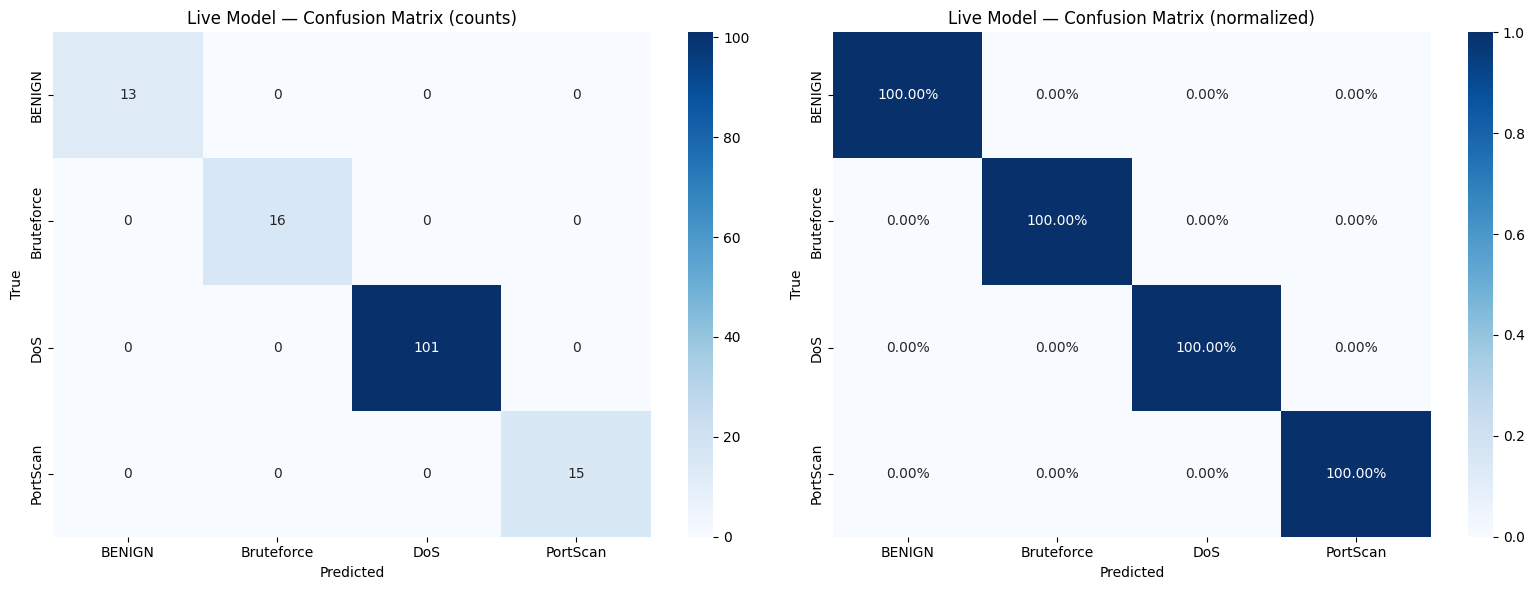

In [10]:
cm = confusion_matrix(y_test, xgb_test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Live Model — Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Live Model — Confusion Matrix (normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrix_live_xgboost.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
benign_idx = (label_encoder.inverse_transform(y_train) == 'BENIGN')
X_train_benign = X_train_scaled[benign_idx]
print(f"Training IF on {len(X_train_benign):,} benign flows")

iso_forest = IsolationForest(
    n_estimators=100, contamination=0.05,
    n_jobs=-1, random_state=RANDOM_STATE,
)
iso_forest.fit(X_train_benign)

iso_preds = iso_forest.predict(X_test_scaled)
iso_anomaly = (iso_preds == -1).astype(int)
y_test_binary = (label_encoder.inverse_transform(y_test) != 'BENIGN').astype(int)

from sklearn.metrics import precision_score, recall_score
iso_p = precision_score(y_test_binary, iso_anomaly, zero_division=0)
iso_r = recall_score(y_test_binary, iso_anomaly, zero_division=0)
print(f"Isolation Forest binary: precision={iso_p:.4f}, recall={iso_r:.4f}")

Training IF on 53 benign flows
Isolation Forest binary: precision=0.0000, recall=0.0000


In [12]:
# Save with the same filenames the detection service expects
# This is what makes the model swap automatic on container restart
joblib.dump(xgb_model, MODELS_DIR / 'xgboost_classifier.pkl')
joblib.dump(iso_forest, MODELS_DIR / 'isolation_forest.pkl')
joblib.dump(scaler, MODELS_DIR / 'feature_scaler.pkl')
joblib.dump(label_encoder, MODELS_DIR / 'label_encoder.pkl')

# Metadata — note: feature_order is now LIVE features, not CICFlowMeter's
metadata = {
    'feature_order': ALL_FEATURES,
    'class_names': class_names.tolist(),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'random_state': RANDOM_STATE,
    'xgb_params': {k: v for k, v in xgb_params.items() if not callable(v)},
    'iso_forest_contamination': 0.05,
    'trained_on': 'live',
    'cv_results': {k: [float(x) for x in v] for k, v in cv_scores.items()},
    'attack_windows_source': str(DATA_DIR / 'attack_windows.json'),
}

with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved live model bundle to {MODELS_DIR}")
print(f"feature_order has {len(ALL_FEATURES)} features (down from CICIDS2017's 65)")

Saved live model bundle to /home/ubuntu/threat-intel-platform/ml/models
feature_order has 19 features (down from CICIDS2017's 65)


In [13]:
test_p, test_r, test_f, _ = precision_recall_fscore_support(
    y_test, xgb_test_preds, average='macro', zero_division=0
)
per_class = precision_recall_fscore_support(
    y_test, xgb_test_preds, average=None, zero_division=0
)

print("=" * 60)
print("LIVE MODEL — FINAL METRICS")
print("=" * 60)
print(f"Test set: {len(y_test):,} flows")
print(f"Macro precision: {test_p:.4f}")
print(f"Macro recall:    {test_r:.4f}")
print(f"Macro F1:        {test_f:.4f}")
print(f"Accuracy:        {accuracy_score(y_test, xgb_test_preds):.4f}")
print(f"\nPER-CLASS:")
for i, name in enumerate(class_names):
    print(f"  {name:12s}  P={per_class[0][i]:.3f}  R={per_class[1][i]:.3f}  F1={per_class[2][i]:.3f}  N={per_class[3][i]}")

final_metrics = {
    'test_macro_precision': float(test_p),
    'test_macro_recall': float(test_r),
    'test_macro_f1': float(test_f),
    'test_accuracy': float(accuracy_score(y_test, xgb_test_preds)),
    'per_class': {
        name: {
            'precision': float(per_class[0][i]),
            'recall': float(per_class[1][i]),
            'f1': float(per_class[2][i]),
            'support': int(per_class[3][i]),
        }
        for i, name in enumerate(class_names)
    },
}

with open(REPORTS_DIR / 'final_test_metrics_live.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(f"\nSaved to {REPORTS_DIR / 'final_test_metrics_live.json'}")

LIVE MODEL — FINAL METRICS
Test set: 145 flows
Macro precision: 1.0000
Macro recall:    1.0000
Macro F1:        1.0000
Accuracy:        1.0000

PER-CLASS:
  BENIGN        P=1.000  R=1.000  F1=1.000  N=13
  Bruteforce    P=1.000  R=1.000  F1=1.000  N=16
  DoS           P=1.000  R=1.000  F1=1.000  N=101
  PortScan      P=1.000  R=1.000  F1=1.000  N=15

Saved to /home/ubuntu/threat-intel-platform/ml/reports/final_test_metrics_live.json
